<div class="alert alert-block alert-info">
¡Hola! Alejandro ¿Cómo vas?

Mi nombre es Santiago Sierra. Un gusto conocerte, seré tu revisor en este proyecto.

A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:

Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.

Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más precisa, junto con algunos ejemplos prácticos. También estoy abierto a responder cualquier duda que tengas.

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.

Puedes encontrar mis comentarios en cuadros verdes, amarillos o rojos como este:
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>

Éxito. Todo se ha hecho de forma correcta.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>

Observación. Algunas recomendaciones o mejoras menores.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>

Necesita arreglos. Este apartado requiere correcciones. El trabajo no puede ser aceptado con comentarios rojos.
</div>

<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:

Respuesta del estudiante.
</div>

<div class="alert alert-block alert-warning">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola! Antes de entrar en el detalle, quiero compartirte mis impresiones generales de esta primera iteración.

Tu redacción analítica es de muy buen nivel: explicas cada hallazgo con precisión técnica, citas cifras exactas y mantienes un tono profesional en todos los diagnósticos. El análisis MAR está bien ejecutado usando `pd.crosstab()`, una alternativa elegante a `.groupby()`. Tu insight ejecutivo también está completo y bien argumentado. ¡Buen trabajo en esos puntos!

Hay un error que impide ejecutar el notebook de principio a fin sin interrupciones, y algunos puntos de consistencia que conviene revisar:

- En la celda 69 usas `user_profile["nivel_uso"]`, pero la columna que creaste se llama `grupo_uso`. Esto generará un error (`KeyError`) al ejecutar esa celda.
- Renombraste la columna como `cant_mensaje` (singular) en lugar de `cant_mensajes` (plural), como pide la instrucción.
- En el diagnóstico de fechas, no se detectó explícitamente el año 2026 como fuera de rango, a pesar de que tu propio código (celda 29) sí lo muestra en el `.unique()`.

Revisemos cada punto con calma. ¡Tienes una base de análisis muy sólida!

Saludos.
</div>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [63]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt # importar librerías

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Perfecto! Importaste `pandas`, `seaborn`, `numpy` y `matplotlib` desde el inicio. Tener `numpy` disponible te permitirá usar `np.select()` más adelante, como de hecho haces. ✅
</div>

In [64]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [65]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [66]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [67]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [68]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [69]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [70]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [71]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente inicio. Verificaste las dimensiones con `.shape` y la estructura con `.info()` para los tres datasets. ✅
</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [72]:
# cantidad de nulos para users
print(users.isna().sum())
print() # línea en blanco
print(  users.isna().sum() / len(users))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [73]:
# cantidad de nulos para usage
print(usage.isna().sum())
print() # línea en blanco
print(  usage.isna().sum() / len(usage))

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien calculando nulos con `.isna().sum()` y la proporción manual (`.isna().sum() / len(df)`), que es equivalente a `.isna().mean()` pero más explícito sobre el cálculo. ✅
</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  

- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En users encontramos dos columnas con valores faltantes, 469 faltantes (11.72% del total) en la columna city, y 3,534 faltantes (88.35% del total) en la columna churn_date
- Indica qué harías: ¿imputar, eliminar, ignorar?
   - En la columna city no se recomienda eliminar los registros, ya que el porcentaje de valores faltantes es relativamente bajo y el resto de la información del usuario permanece disponible para el análisis. Dependiendo de los objetivos posteriores del proyecto, estos valores podrían mantenerse como faltantes o imputarse mediante una categoría como "Desconocido"
  - En la columna churn_date tampoco se recomienda eliminar los registros, ya que la ausencia de datos parece tener significado analítico. Un valor nulo probablemente indica que el usuario no ha abandonado el servicio, por lo que no representa un error de captura sino una condición válida dentro del negocio. Por esta razón, los valores faltantes deben conservarse y considerarse como parte de la información relevante para el análisis del abandono de clientes.
    

  - Los valores ausentes observados en las columnas duration y length responden a la naturaleza de la base de datos, la cual integra tanto registros de llamadas como de mensajes de texto. Por ello, la ausencia de información en estas variables no representa un error de captura o calidad de datos, sino que indica que el registro corresponde a un tipo de operación distinto. En consecuencia, los valores faltantes pueden considerarse esperados y coherentes con la estructura del conjunto de datos.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Excelente diagnóstico! Identificas con precisión las proporciones de cada columna y razonas cada decisión con criterio: especialmente valioso es tu análisis de `churn_date`, donde reconoces que el nulo tiene significado de negocio (usuario activo) en lugar de tratarlo como un error. También anticipas correctamente que los nulos en `duration` y `length` están relacionados con `type`. ✅
</div>

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [74]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000




- La columna `user_id` corresponde a un identificador único de usuario. Aunque es una variable numérica y permite obtener estadísticas descriptivas, estas no tienen relevancia analítica debido a que su función es únicamente identificar registros.
  
- En la columna `age` se observa una edad máxima de 79 años, valor que resulta consistente para la población analizada. Sin embargo, el valor mínimo registrado es de -999 años, lo que sugiere la presencia de un valor centinela o un error de captura. Debido a la existencia de este valor atípico, la media (33.74 años) y la desviación estándar (123.23 años) pueden encontrarse distorsionadas. En particular, una desviación estándar superior a 100 años resulta poco probable para una variable de edad, por lo que será necesario investigar el origen de los valores negativos y determinar si deben corregirse, imputarse o excluirse antes de continuar con el análisis.



<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Muy buena observación distinguiendo entre `user_id` (un identificador sin valor analítico) y `age` (donde sí detectas el sentinel `-999`). Ese tipo de criterio es justo lo que se espera de un analista: no toda columna numérica merece la misma interpretación. ✅
</div>

In [75]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Las columnas `id` y `user_id`corresponden a identificadores únicos de cada registro (llamada o mensaje) y del usuario asociado, respectivamente. Aunque son variables numéricas y permiten obtener estadísticas descriptivas, estas carecen de valor analítico directo debido a que su función principal es identificar registros y establecer relaciones entre tablas.

- La columna `duration` indica que, de los 40,000 registros analizados, 17,924 corresponden a llamadas telefónicas. La duración promedio de las llamadas es de aproximadamente 5.20 minutos. Además, el percentil 75 muestra que el 75% de las llamadas tienen una duración igual o inferior a 6.99 minutos, mientras que únicamente el 25% supera dicha duración.

- La columna `lebgth` indica que, de los 40,000 registros analizados, 22,104 corresponden a mensajes de texto. La longitud promedio registrada es de aproximadamente 52 unidades. Considerando el contexto de la variable, es razonable inferir que dicha medida corresponde al número de caracteres por mensaje, aunque esta interpretación debería confirmarse mediante la documentación del dataset.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buena lectura del `.describe()` de `usage`, incluyendo cifras concretas de duración promedio y percentiles. La hipótesis sobre `length` representando caracteres por mensaje es razonable y bien matizada al reconocer que necesitaría confirmación con la documentación del dataset. ✅
</div>

In [76]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

users[columnas_user].value_counts()




city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

In [77]:
# explorar columna categórica de usage
for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print() # completa el código

city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

La intención de explorar las columnas categóricas es correcta, pero `users[columnas_user].value_counts()` sobre **dos columnas a la vez** genera combinaciones de pares `(city, plan)` en lugar de los valores únicos de cada columna por separado. Esto hace más difícil leer cuántos valores únicos tiene cada columna individualmente.

La forma recomendada es explorar cada columna por separado:

```python
for col in columnas_user:
    print(col)
    print(users[col].value_counts(dropna=False))
    print()
```
</div>

La columna type identifica el tipo de comunicación registrada en la base de datos. Se observan dos categorías:

text: 22,092 registros (55.23% del total).
call: 17,908 registros (44.77% del total).

Lo que demuestra que existe en los usuarios una preferencia por el uso de mensajes de texto.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente diagnóstico de `type`: incluyes los conteos exactos, los porcentajes calculados y una interpretación de negocio razonable (preferencia por mensajes de texto). ✅
</div>

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? e identificaron 96 registros con valores potencialmente inválidos o incompletos. De ellos, 65 registros contienen el valor "?", el cual parece utilizarse como un valor centinela para representar una ciudad desconocida o no capturada. Adicionalmente, 31 registros presentan valores faltantes asociados a la ciudad
- ¿Qué acción tomarías?  Antes de realizar cualquier análisis por ciudad, se recomienda reemplazar el valor "?" por NaN, ya que ambos representan información desconocida. Posteriormente, los registros pueden mantenerse como valores faltantes para evitar introducir sesgos mediante imputaciones arbitrarias. Debido a que estos registros representan únicamente el 2.4% del total de usuarios (96 de 4,000), su impacto sobre el análisis general es reducido.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Muy buen diagnóstico! Identificas correctamente los 65 registros con `"?"` y los 31 con valores faltantes reales en `city` (aunque, dado el comentario anterior sobre `value_counts()` en dos columnas, te recomiendo confirmar estos números explorando `city` de forma individual). La acción propuesta —reemplazar `"?"` por `NaN` y dejarlo como faltante sin imputar— es exactamente la estrategia correcta según las instrucciones. ✅
</div>

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [78]:
# Convertir a fecha la columna `reg_date` de users
# completa el código
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [79]:
# Convertir a fecha la columna `date` de usage
# completa el código
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Bien! Usaste `errors="coerce"` en ambas conversiones, lo que hace el código robusto ante valores no convertibles a fecha. ✅
</div>

In [80]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En 'reg_date' se identificaron registros para los años 2022, 2023, 2024 y 2026. Considerando que el análisis se limita al año 2024, los 40 registros correspondientes a 2026 (1.0% del total) representan fechas futuras e inconsistentes con el periodo de estudio, por lo que serán tratadas como valores ausentes para los análisis posteriores.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Tu código con `.unique()` muestra correctamente que aparece el año **2026** en `reg_date`. Sin embargo, en el diagnóstico textual te enfocas en la "ausencia del año 2025" como lo llamativo, sin señalar explícitamente que **2026 es un año futuro imposible** dado que los datos llegan hasta 2024 (como indica la consigna del proyecto). Ese es justamente el sentinel que se espera detectar en esta sección.

Además, te recomiendo usar `.value_counts()` en lugar de `.unique()`, ya que te permite ver cuántos registros hay en cada año, no solo qué años existen:

```python
users["reg_date"].dt.year.value_counts().sort_index()
```

Esto te mostraría claramente los 40 registros del 2026 que necesitan corrección.
</div>

In [81]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Buen uso de `.value_counts()` aquí, identificando correctamente que la gran mayoría de `date` corresponde a 2024 y que existen 50 registros sin año identificable (0.13%), con una conclusión razonable sobre su impacto mínimo. ✅
</div>

En `date`, se identificó que 39,950 registros de uso corresponden al año 2024, por lo que el análisis se delimitará a dicho periodo. Asimismo, se detectaron 50 registros para los cuales no fue posible identificar el año debido a la ausencia o invalidez de la fecha registrada. Dado que estos representan únicamente el 0.13% del total de observaciones, su impacto sobre el análisis general se considera mínimo; sin embargo, será necesario revisar su origen para determinar el tratamiento más adecuado.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Sí. En la columna reg_date se identificaron 40 registros correspondientes al año 2026. Considerando que el conjunto de datos se limita al año 2024, estas fechas representan valores futuros e inconsistentes con el periodo de análisis.
- ¿Qué harías con ellas? Debido a que los registros de 2026 representan únicamente el 1.0% de la base de datos (40 de 4,000 usuarios), se conservarán los registros, pero las fechas serán marcadas como valores ausentes (pd.NaT) para evitar que afecten los análisis posteriores relacionados con fechas.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Aquí está el problema central de esta sección: el diagnóstico afirma **"No existen años imposibles"**, pero tu propio código (celda 29) muestra que `reg_date` contiene el año **2026**, que sí es imposible dado que el proyecto establece que los datos llegan hasta 2024.

Esto importa porque, si el diagnóstico no reconoce el problema, no queda claro en el notebook por qué sería necesario corregirlo (aunque, como verás en la celda 37, tu código de limpieza sí termina aplicando la corrección correcta).

Te recomiendo actualizar el diagnóstico para reconocer explícitamente el sentinel del 2026:

*"Se identificó un año imposible (2026) en 40 registros de reg_date, dado que el límite de los datos es 2024. Estos registros se marcarán como pd.NaT."*
</div>

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [82]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, pd.NA)
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Correcto. El enfoque de reemplazar `-999` por `pd.NA` primero y luego usar `.fillna()` con la mediana es una forma válida y clara de lograr el mismo resultado que reemplazar directamente con `.replace(-999, mediana)`. ✅
</div>

In [83]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Perfecto! Reemplazaste `"?"` por `pd.NA` y verificaste con `.value_counts(dropna=False)`, la forma ideal de confirmar que los nulos quedaron correctamente registrados. ✅
</div>

In [84]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, other = pd.NaT)

# Verificar cambios
users['reg_date'].dt.year.unique()


array([2022.,   nan, 2023., 2024.])

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Excelente! Usaste `.where(condición, other=pd.NaT)` como alternativa a `.loc[]`, que es igualmente válida: conserva los valores que cumplen la condición (año ≤ 2024) y reemplaza el resto con `pd.NaT`. El resultado es correcto. ✅

Recuerda actualizar el diagnóstico de la celda anterior para reconocer que el 2026 sí era un problema, ya que tu código aquí demuestra que sabías que había que corregirlo.
</div>

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [85]:

# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    margins=True
)


duration,False,True,All
type,,,
call,17908,0,17908
text,16,22076,22092
All,17924,22076,40000


In [86]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    margins=True
)



length,False,True,All
type,,,
call,12,17896,17908
text,22092,0,22092
All,22104,17896,40000



Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

La revisión de los valores faltantes en duration muestra que la ausencia de información depende principalmente del tipo de comunicación. Sin embargo, se identificaron 16 registros clasificados como text que contienen una duración registrada. Debido a que los mensajes de texto no poseen una duración asociada, estos registros deberán ser revisados para determinar si corresponden a errores de captura o a una característica particular del conjunto de datos.

La revisión de los valores faltantes en length muestra que la ausencia de información depende principalmente del tipo de comunicación. Sin embargo, se identificaron 12 registros clasificados como call que contienen una longitud registrada. Debido a que las llamadas telefónicas no poseen una longitud de mensaje asociada, estos registros deberán ser revisados para determinar si corresponden a errores de captura o a una característica particular del conjunto de datos.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Excelente uso de `pd.crosstab()` con `margins=True` para el análisis MAR! Es una alternativa muy clara visualmente a `.groupby()`, ya que muestra la tabla de contingencia completa entre `type` y la condición de nulo.

Además, tu diagnóstico tiene un nivel de detalle que va más allá de lo esperado: notaste que existen 16 registros de tipo `text` con `duration` registrada (y 12 de tipo `call` con `length` registrada), lo cual son inconsistencias menores que merecen revisión aparte del patrón MAR principal. Ese tipo de observación granular demuestra un ojo analítico muy fino. ✅
</div>

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [87]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [88]:
# Renombrar columnas
usage_agg = usage_agg.rename(
    columns = {
        'is_text' : 'cant_mensajes',
        'is_call' : 'cant_llamadas',
        'duration' : 'cant_minutos_llamada'
    }
)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

La lógica de agrupación con `.groupby().agg()` es correcta. ✅

Un detalle de nomenclatura: renombraste la columna como `cant_mensaje` (singular), pero la instrucción pide específicamente `cant_mensajes` (plural). Esto no rompe el código en sí, pero sí genera una inconsistencia con el nombre exacto solicitado, y tendrás que usar `cant_mensaje` (singular) en el resto del notebook, lo que puede generar confusión si alguien compara tu trabajo con la consigna original. Te recomiendo corregirlo:

```python
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
```
</div>

In [89]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on = 'user_id',
    how = 'left'
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El merge con `how="left"` es correcto y conserva todos los usuarios. ✅
</div>

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [90]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[columnas_numericas].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [91]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

La distribución porcentual del plan está perfecta: usaste `normalize=True` correctamente sobre `user_profile`. ✅

Sobre el resumen estadístico: `user_profile.describe()` sin filtrar columnas incluye todas las variables numéricas, entre ellas `user_id`, que no aporta valor analítico. Te recomiendo enfocarte en las columnas relevantes para que el resumen sea más directo:

```python
columnas_numericas = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile[columnas_numericas].describe()
```
</div>

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

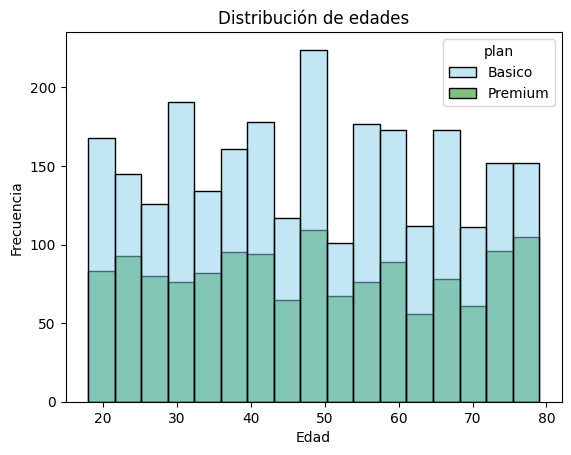

In [92]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data = user_profile, x = 'age', hue='plan', palette=['skyblue','green'])
plt.title("Distribución de edades")
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- El histograma muestra que las edades de los usuarios de ambos planes se distribuyen a lo largo de un rango similar, sin evidenciar diferencias claras entre ellos. Aunque esta visualización cumple el objetivo de explorar la distribución de la variable, no permite identificar patrones diferenciados entre planes. Se recomienda complementar el análisis con un boxplot o estadísticas descriptivas por grupo para facilitar la comparación.

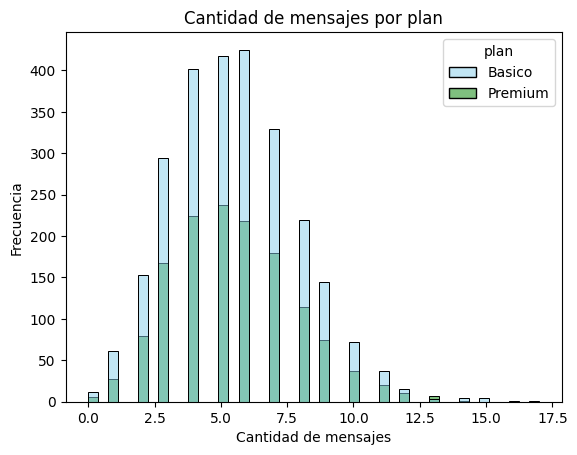

In [95]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data = user_profile, x = 'cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title("Cantidad de mensajes por plan")
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()




💡Insights: 
- La distribución del número de mensajes presenta una concentración principal entre 4 y 7 mensajes por usuario, con una moda cercana a los 5 mensajes. Asimismo, se observa una ligero sesgo a la derecha, donde un grupo reducido de usuarios registra cantidades de mensajes considerablemente mayores al promedio. Visualmente, las distribuciones de los planes Básico y Premium muestran patrones similares, por lo que no se identifican diferencias claras en el comportamiento de mensajería únicamente a partir de este histograma.

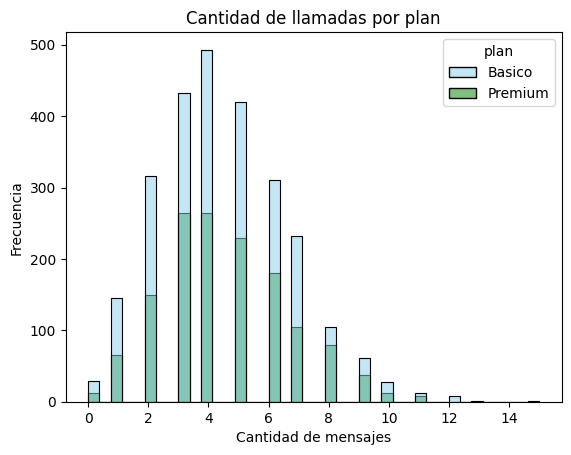

In [96]:

# Histograma para visualizar la cant_llamadas

sns.histplot(data = user_profile, x = 'cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title("Cantidad de llamadas por plan")
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()






💡Insights: 
- La distribución del número de llamadas presenta una concentración principal entre 2 y 6 llamadas por usuario, con una moda cercana a las 5 llamadas. Asimismo, se observa una ligero sesgo a la derecha, donde un grupo reducido de usuarios registra cantidades de llamads considerablemente mayores al promedio. Visualmente, las distribuciones de los planes Básico y Premium muestran patrones similares, por lo que no se identifican diferencias claras en el comportamiento de llamadas únicamente a partir de este histograma.

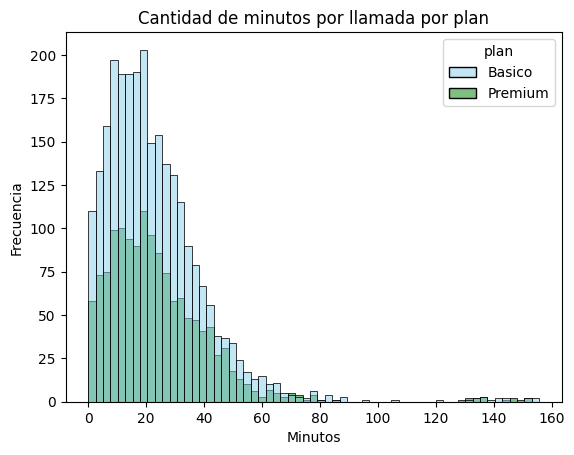

In [97]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data = user_profile, x = 'cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title("Cantidad de minutos por llamada por plan")
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()




<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Los cuatro histogramas están bien construidos con `hue="plan"`, títulos y etiquetas. Tus insights son notablemente reflexivos: en el primero, reconoces honestamente que el histograma de `age` no permite ver diferencias claras entre planes y sugieres complementar con boxplot, que es justo lo que harás en la siguiente sección. En el de minutos, detectas una posible mayor concentración de usuarios Premium en los valores altos, una observación de negocio valiosa. ✅
</div>

💡Insights: 
- La distribución de minutos de llamadas muestra una concentración principal entre los 10 y 30 minutos para ambos planes. Asimismo, se observa una marcada asimetría positiva, donde la mayoría de los usuarios presenta consumos moderados y un grupo reducido registra niveles significativamente superiores. En los valores más altos de consumo se aprecia una mayor presencia relativa de usuarios del plan Premium, lo que sugiere que este plan podría concentrar una mayor proporción de usuarios intensivos en el uso de llamadas. Sin embargo, esta hipótesis deberá validarse mediante el análisis de estadísticas descriptivas por grupo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

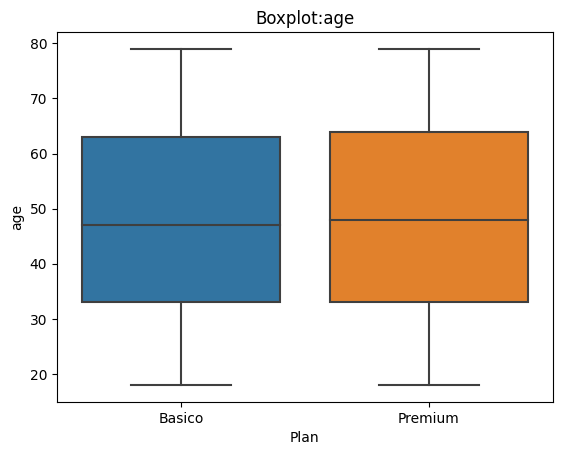

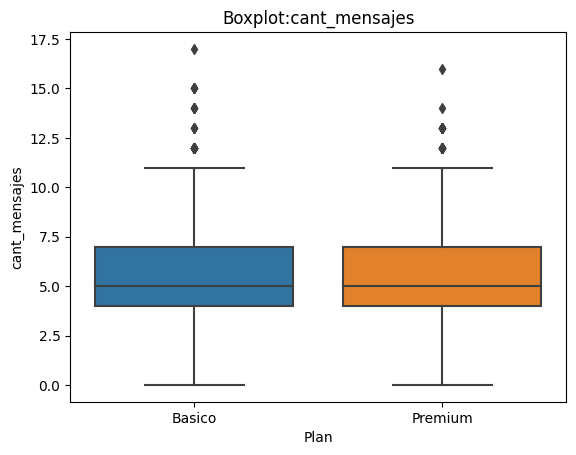

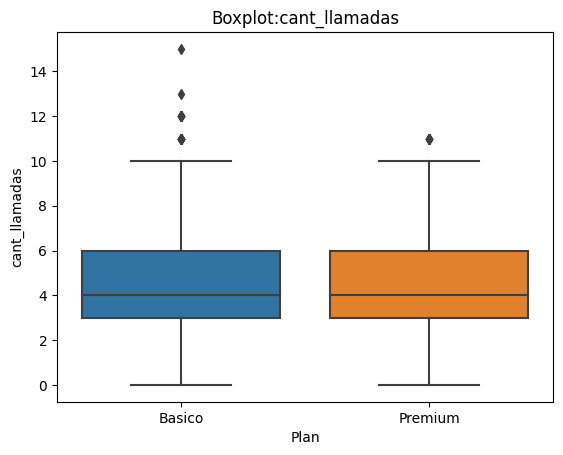

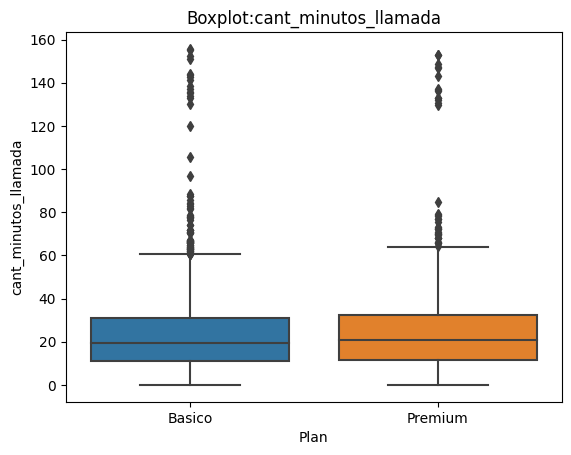

In [101]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(
        data = user_profile,
        x = 'plan',
        y = col
    )
    plt.title (f'Boxplot:{col}')
    plt.xlabel('Plan')
    plt.ylabel(col)

    plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien usando el bucle `for` con `x="plan"` para separar los boxplots por plan, lo que sí permite comparar directamente entre Básico y Premium (resolviendo la limitación que notaste en los histogramas). ✅
</div>

💡Insights: 
- Age: No presenta outlier
- cant_mensajes: existen pocos outliers para ambos planes
- cant_llamadas: existen pocos outliers para ambos planes
- cant_minutos_llamada: presenta un alto número de ouliers en ambos planes

In [102]:
# Calcular límites con el método IQR

columnas_limites = []

for col in columnas_numericas:

    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    columnas_limites.append(
        [col, limite_inferior, limite_superior]
    )



In [103]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
for limite in columnas_limites:
    print(limite)

['age', -12.0, 108.0]
['cant_mensajes', -0.5, 11.5]
['cant_llamadas', -1.5, 10.5]
['cant_minutos_llamada', -19.322500000000005, 61.8575]


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Perfecto! Calculaste el límite inferior y superior con IQR para las cuatro columnas y los almacenaste en una lista de listas para revisarlos ordenadamente. Es un enfoque limpio y reutilizable. ✅
</div>

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Se identificaron algunos valores por encima del límite calculado mediante el método IQR. Sin embargo, al revisar la distribución de los datos, estos registros parecen corresponder a usuarios que envían una cantidad de mensajes mayor al promedio y no a errores de captura. Por esta razón, se decidió mantenerlos en el análisis.
- cant_llamadas: mantener o no outliers, porqué? Aunque existen usuarios con un número de llamadas superior al límite calculado, este comportamiento resulta posible dentro del contexto del servicio. Estos registros pueden representar usuarios con un uso más frecuente de las llamadas, por lo que se conservarán para no perder información relevante.
- cant_minutos_llamada: mantener o no outliers, porqué? Esta variable presenta varios valores por encima del límite superior, algo que ya se observaba en el histograma mediante una cola hacia la derecha. Dado que estos registros parecen reflejar usuarios con un consumo elevado de minutos y no valores incorrectos, se decidió mantenerlos en la base de datos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Excelente justificación para mantener los outliers en las tres variables: conectas cada decisión con el contexto de negocio (usuarios con consumo elevado, no errores de captura). ✅
</div>

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [104]:
# Crear columna grupo_uso

condiciones = [
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),

    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10)
]

categorias = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    categorias,
    default='Alto uso'
)


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Buen uso de `np.select()`! Las dos condiciones explícitas más el `default="Alto uso"` son matemáticamente equivalentes a la lógica de `if/elif/else` pedida, y el resultado es correcto. ✅
</div>

In [105]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [106]:
# Crear columna grupo_edad
rangos = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

grupos = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(
    rangos,
    grupos,
    default='Adulto Mayor'
)


In [107]:
# verificar cambios
user_profile.head()

pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso'],
    margins=True
)

grupo_uso,Alto uso,Bajo uso,Uso medio,All
grupo_edad,,,,
Adulto,154,364,1500,2018
Adulto Mayor,74,257,891,1222
Joven,51,157,552,760
All,279,778,2943,4000


<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

La segmentación `grupo_edad` con `np.select()` (celda 68) es correcta. ✅

Sin embargo, hay un error en la celda 69 que impedirá ejecutar el notebook de principio a fin:

```python
pd.crosstab(
    user_profile["grupo_edad"],
    user_profile["nivel_uso"],  # <- esta columna no existe
    margins=True
)
```

La columna que creaste en la celda 65 se llama `grupo_uso`, no `nivel_uso`. Al ejecutar esta celda con el nombre incorrecto obtendrás un `KeyError`.

Como dato curioso: esta tabla de contingencia no estaba pedida explícitamente en las instrucciones, pero es un análisis interesante que anticipa el insight ejecutivo sobre edad vs. nivel de uso. Una vez corregido el nombre de columna, puedes dejarla como un análisis adicional.
</div>

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

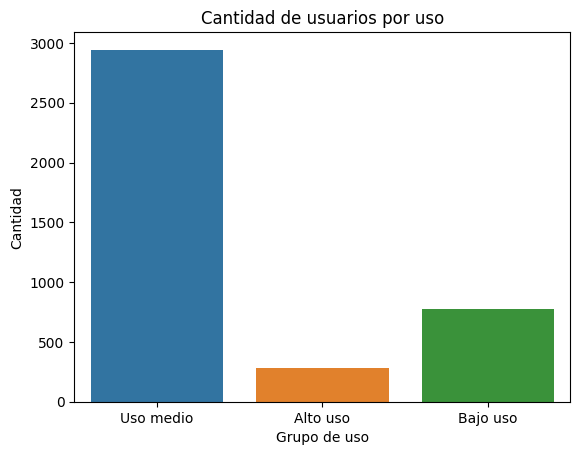

In [108]:
# Visualización de los segmentos por uso
sns.countplot(
    data = user_profile,
    x = 'grupo_uso'
)
plt.title('Cantidad de usuarios por uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad')
plt.show()



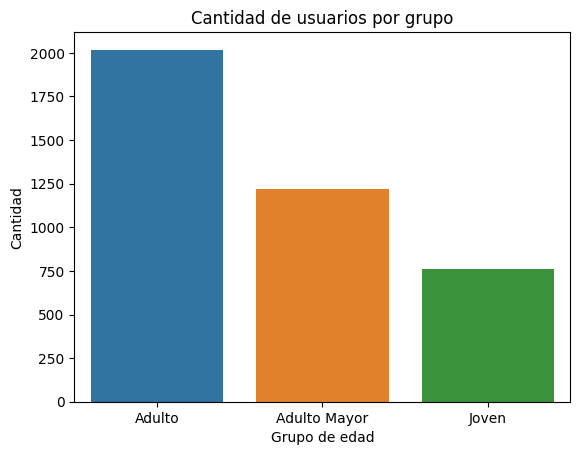

In [109]:
# Visualización de los segmentos por edad
sns.countplot(
    data = user_profile,
    x = 'grupo_edad'
)
plt.title('Cantidad de usuarios por grupo')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad')
plt.show()



<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Los dos `countplot` están bien generados con títulos y etiquetas en ambos ejes. ✅
</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**





### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Durante la exploración de los datos se identificaron valores faltantes en las columnas city y churn_date de la tabla de usuarios.
- Los 469 valores faltantes en city representaban aproximadamente el 11.7% de los registros.
- Los 3,534 valores faltantes en churn_date correspondían al 88.4% de los usuarios. En este último caso, los valores ausentes no fueron considerados un error, ya que indican usuarios que no han abandonado el servicio.
- También se identificaron valores sentinela en la columna age, donde algunos registros contenían el valor -999, lo que generaba distorsiones importantes en las estadísticas descriptivas. Estos registros fueron tratados antes de continuar con el análisis.
- Se detectaron inconsistencias menores entre el tipo de comunicación y las variables asociadas, como mensajes con duración registrada o llamadas con longitud de mensaje, aunque representaban una proporción mínima del conjunto de datos.



🔍 **Segmentos por Edad**
- Aunque se identificaron tres segmentos etarios (jóvenes, adultos y adultos mayores), no se observan diferencias relevantes en los niveles de uso entre ellos. En los tres grupos predomina el uso medio, con participaciones cercanas al 73%, mientras que los usuarios de alto uso representan aproximadamente entre el 6% y el 8% de cada segmento.
- La edad no parece ser una variable con alto poder de segmentación para explicar el comportamiento de consumo. Los patrones de uso observados son relativamente homogéneos entre los distintos grupos etarios.


📊 **Segmentos por Nivel de Uso**
- Se identificaron tres segmentos de consumo: Bajo uso (778 usuarios, 19.5%), Uso medio (2,943 usuarios, 73.6%) y Alto uso (279 usuarios, 7.0%).
- El segmento predominante corresponde a los usuarios de uso medio, concentrando casi tres cuartas partes de la base de clientes. Por el contrario, los usuarios de alto uso representan una proporción reducida de la cartera, aunque potencialmente generan una mayor demanda de los servicios ofrecidos.


➡️ Esto sugiere que:
- El comportamiento de consumo parece ser una variable de segmentación más relevante que la edad, ya que los patrones de uso son consistentes entre los distintos grupos etarios.
- La mayor oportunidad comercial se encuentra en comprender las necesidades de los usuarios de uso medio y alto, dado que concentran la mayor actividad dentro de la plataforma y podrían responder favorablemente a ofertas o beneficios diferenciados.

💡 **Recomendaciones**
- Evaluar la creación de beneficios específicos para usuarios de alto uso, como paquetes con mayor capacidad de llamadas o mensajes, con el objetivo de incrementar la retención y satisfacción de este segmento.
- Analizar la posibilidad de desarrollar planes intermedios orientados a los usuarios de uso medio, quienes representan la mayoría de la cartera y podrían constituir el principal mercado objetivo para futuras estrategias comerciales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`